<a href="https://colab.research.google.com/github/jhonquimi-png/Aprendizaje_Automatico/blob/main/notebooks/S3_Modelos_aprendizaje_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Modelos de aprendizaje no supervisado

In [27]:
# Parte 1: Preparación del entorno
#!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

##1. Preparación del entorno

In [28]:
!git config --global user.email "jhon.quimi@uees.edu.ec"
!git config --global user.name "jhonquimi-png"

##2. Selección del dataset
Usar un datasets validado por el docente:

In [29]:
# ── 0.2 Carga del dataset ──────────────────────────────────────────────────────
url_github = 'https://raw.githubusercontent.com/jhonquimi-png/Aprendizaje_Automatico/refs/heads/main/data/student_performance.csv'
df1 = pd.read_csv(url_github, low_memory=False)
print(f'Dataset cargado: {df1.shape[0]:,} filas × {df1.shape[1]} columnas')

Dataset cargado: 500 filas × 11 columnas


In [30]:
df = df1.copy()
print(df)

    student_id  gender  age  study_hours_per_week  attendance_rate  \
0      STU0001    Male   15                    25             63.8   
1      STU0002  Female   15                     2             54.7   
2      STU0003  Female   19                    10             90.5   
3      STU0004    Male   16                    26             66.8   
4      STU0005  Female   15                    25             73.0   
..         ...     ...  ...                   ...              ...   
495    STU0496  Female   19                     6             78.3   
496    STU0497  Female   16                    27             61.1   
497    STU0498  Female   18                    16             72.3   
498    STU0499    Male   17                    29             91.3   
499    STU0500    Male   15                    29             75.4   

    parent_education internet_access extracurricular  previous_score  \
0           Bachelor             Yes             Yes              41   
1           Bac

##3. Análisis exploratorio

*   Análisis estadístico
*   Visualización de correlaciones y distribución
*   Eliminación de columnas irrelevantes o transformación de variables




**Describir variables y clases.**

Acerca del conjunto de datos

Este conjunto de datos para practicar la clasificación y regresión mediante aprendizaje automático. Contiene 500 registros de estudiantes con sus hábitos de estudio, datos demográficos y resultados de exámenes.

Las columnas incluyen información como horas de estudio semanales, tasa de asistencia, nivel educativo de los padres, calificaciones anteriores y calificaciones finales. La variable objetivo puede utilizarse final_scorepara regresión o passedclasificación (aprobar = puntuación >= 50).

Descripción de variables y clases

*   student_id:Identificador único de estudiante (STU0001-STU0500)
*   gender: Género del estudiante (Masculino/Femenino)
*   age: Edad del estudiante en años
*   study_hours_per_week: Horas de estudio semanales autoinformadas
*   attendance_rate: Porcentaje de asistencia a clase (0-100)
*   parent_education: Nivel educativo más alto de los padres
*   internet_access: Si el estudiante tiene internet en casa (Sí/No)
*   extracurricular: ¿El estudiante participa en actividades extracurriculares? (Sí/No)
*   previous_score: Puntuación del trimestre anterior (0-100)
*   final_score: Puntuación del examen final (0-100)
*   passed: aprueba o no el estudiante

/tmp/ipykernel_11552/588133828.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passed', data=df, ax=axes[1], palette='viridis')


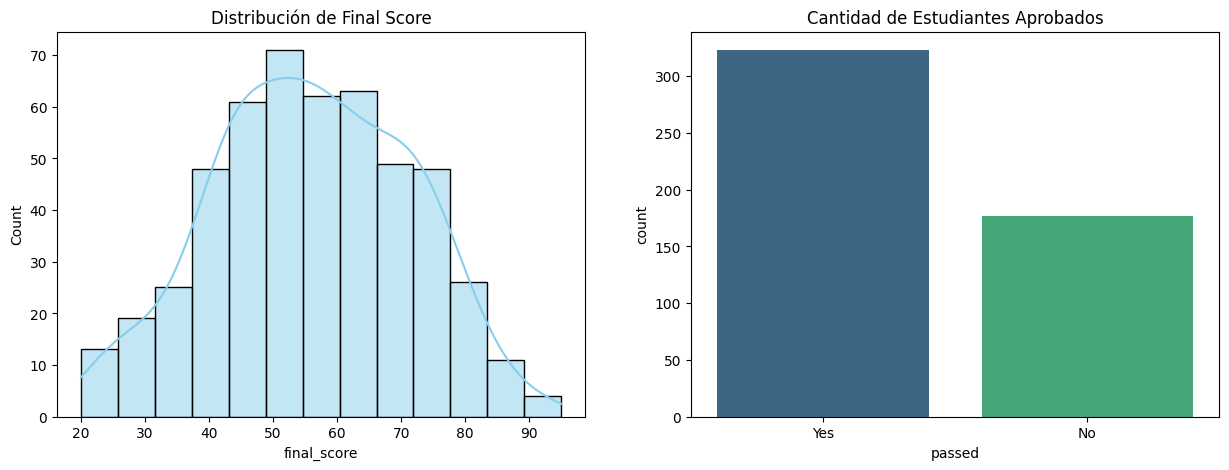

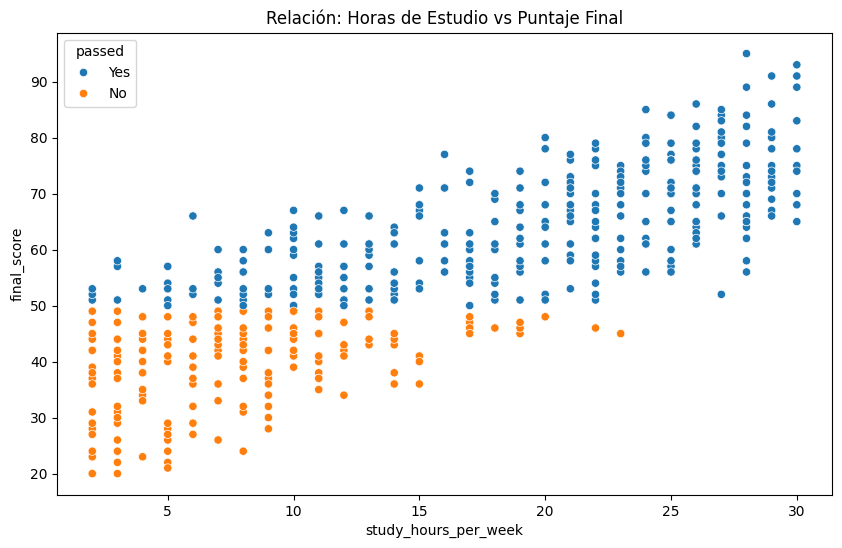

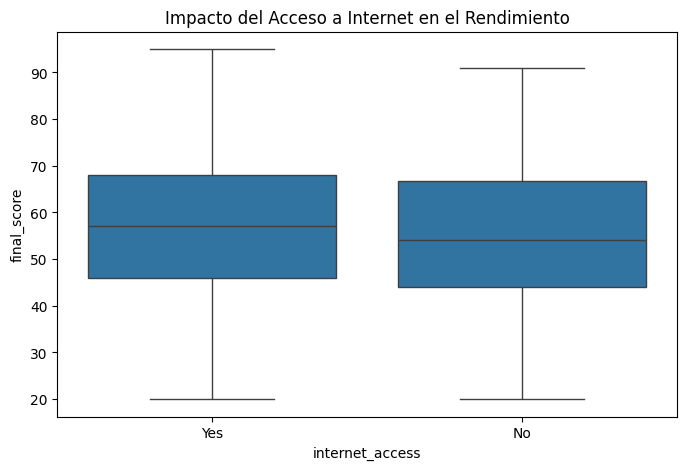

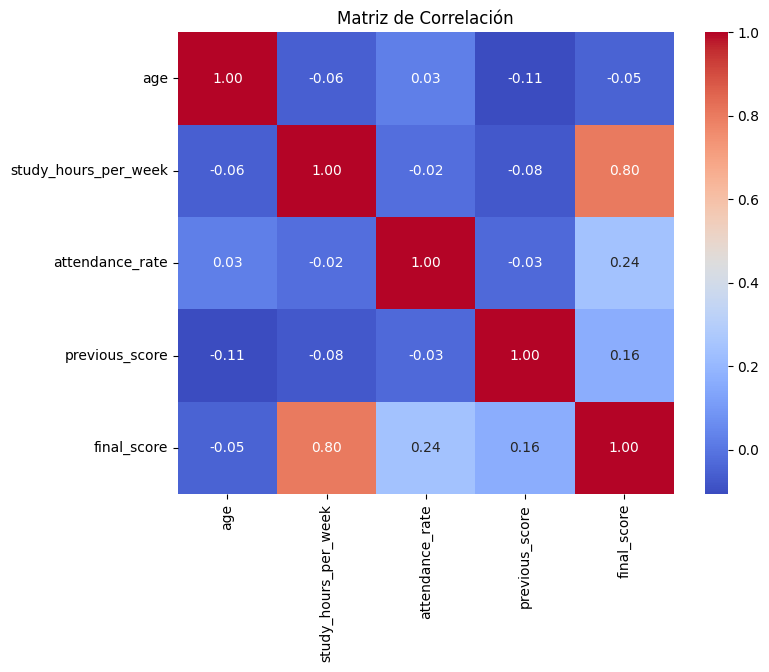

              age  study_hours_per_week  attendance_rate  previous_score  \
count  500.000000            500.000000       500.000000      500.000000   
mean    16.978000             15.312000        76.380600       62.986000   
std      1.434445              8.568167        13.817681       18.937451   
min     15.000000              2.000000        50.200000       30.000000   
25%     16.000000              8.000000        64.475000       46.000000   
50%     17.000000             15.000000        76.500000       64.000000   
75%     18.000000             23.000000        88.525000       79.000000   
max     19.000000             30.000000       100.000000       95.000000   

       final_score  
count   500.000000  
mean     55.980000  
std      15.373754  
min      20.000000  
25%      45.000000  
50%      56.000000  
75%      68.000000  
max      95.000000  


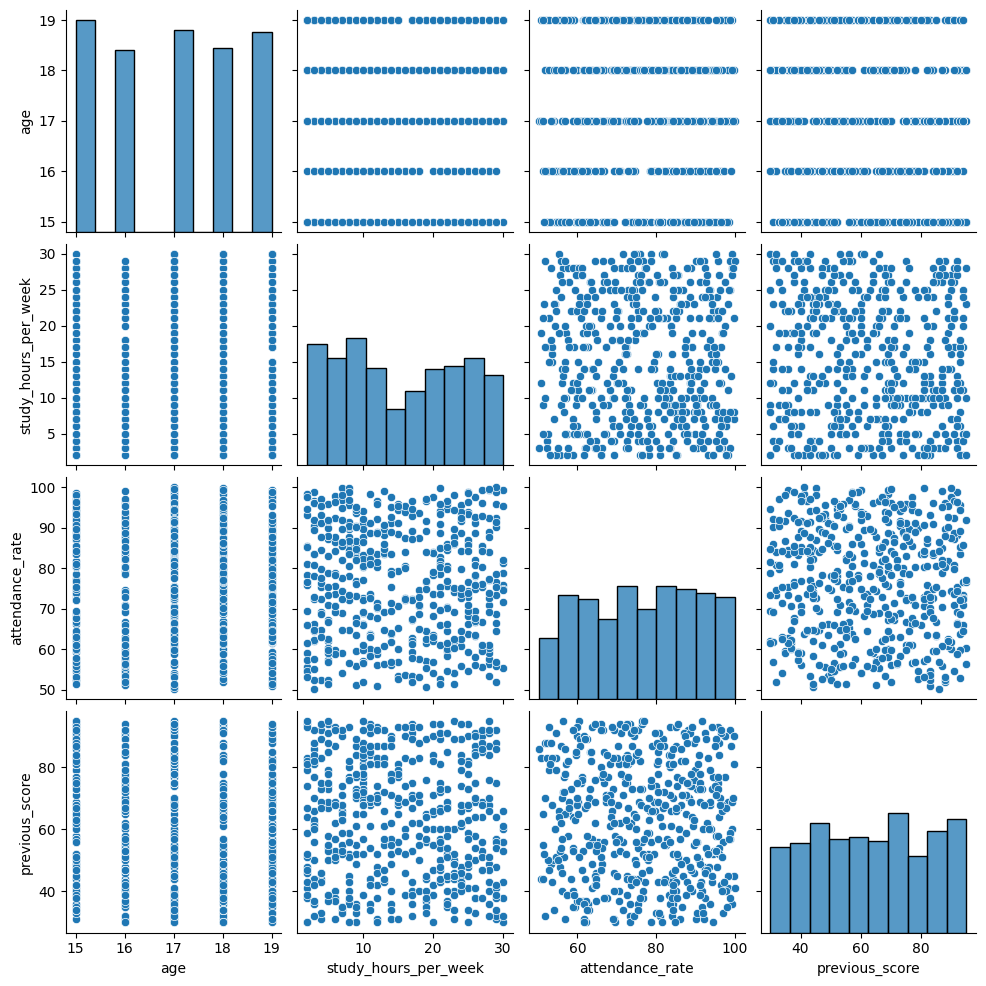

In [31]:
#  Análisis Univariante (Distribuciones)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del puntaje final
sns.histplot(df['final_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Final Score')

# Conteo de aprobados vs reprobados
sns.countplot(x='passed', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Cantidad de Estudiantes Aprobados')
plt.show()

# Análisis Bivariante (Relaciones)
plt.figure(figsize=(10, 6))

# ¿Más horas de estudio significan mejor nota?
sns.scatterplot(x='study_hours_per_week', y='final_score', hue='passed', data=df)
plt.title('Relación: Horas de Estudio vs Puntaje Final')
plt.show()

# Impacto del acceso a internet en el puntaje
plt.figure(figsize=(8, 5))
sns.boxplot(x='internet_access', y='final_score', data=df)
plt.title('Impacto del Acceso a Internet en el Rendimiento')
plt.show()

# Matriz de Correlación (Solo variables numéricas)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

print(df.describe())

# Visualización de la distribución
sns.pairplot(df[['age', 'study_hours_per_week', 'attendance_rate','previous_score']])
plt.show()

Interpretación del EDA

Los datos muestran un grupo de estudiantes con una edad promedio de 17 años y un comportamiento académico muy variado, destacando que el final_score promedio (55.98) es notablemente inferior al del trimestre anterior (62.98), lo que sugiere un aumento en la dificultad de la evaluación o un descenso en el rendimiento. Existe una dispersión considerable en los hábitos de estudio, con alumnos que dedican desde 2 hasta 30 horas semanales, mientras que la asistencia se mantiene en niveles aceptables, superando siempre el 50%
Finalmente, dado que la mediana del puntaje final es 56 y el umbral de aprobación es 50, se interpreta que más de la mitad de la muestra logró aprobar, aunque el 25% de los estudiantes se encuentra en una zona de riesgo con calificaciones de 45 puntos o menos.



###**Implementación de modelos**

**¿Por qué es necesario escalar para K-Means y DBSCAN?**

Ambos algoritmos usan distancias (por ejemplo, distancia euclidiana) para agrupar los datos. Si una variable tiene un rango mucho mayor que otra, dominará la distancia total y, por lo tanto, tendrá más peso en la decisión del algoritmo, aunque no necesariamente sea más importante.


In [32]:
# Escalamiento de variables
X = df[['age', 'study_hours_per_week', 'attendance_rate','previous_score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Comentario:** Se consideró las variables edad, hora de estudio por semana, porcentaje de asistencia a clases y score previo de calificación, porque son las variables numéricas escalares del DataSet para ser utilizadas en el modelo

###**K-Means Clustering**

Es un algoritmo no supervisado que divide los datos en K grupos (clusters) con base en la distancia entre puntos. Cada grupo se forma alrededor de un centroide. El objetivo es minimizar la distancia total entre los puntos y su centroide.

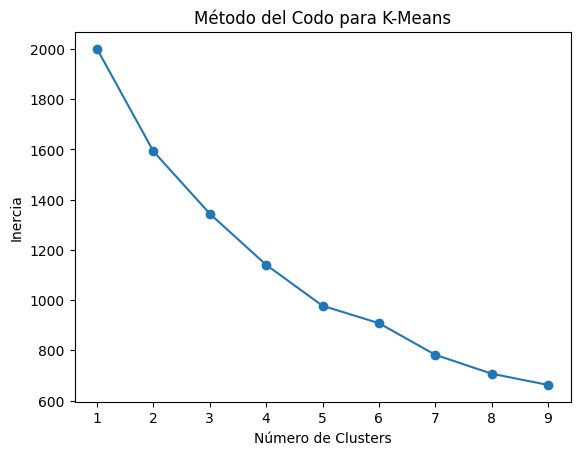

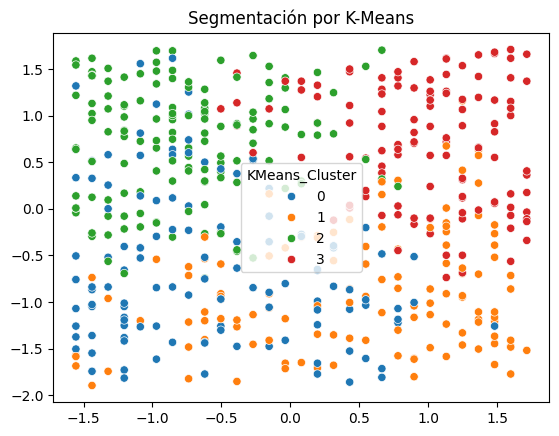

In [33]:
# Clustering con K-Means
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Método del Codo
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Número de Clusters') # Numero de grupos
plt.ylabel('Inercia') # la suma de las distancias cuadradas de cada punto a su centroide (cuánto error hay dentro de cada cluster).
plt.title('Método del Codo para K-Means')
plt.show()

# Ajuste del modelo con K óptimo
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=df['KMeans_Cluster'], palette='tab10')
plt.title('Segmentación por K-Means')
plt.show()

In [34]:
#  Interpretación de Clustering con K-Means
df.groupby('KMeans_Cluster')[['age', 'study_hours_per_week', 'attendance_rate','previous_score']].mean()

,age,study_hours_per_week,attendance_rate,previous_score
KMeans_Cluster,,,,
0,17.691667,10.208333,68.080000,47.008333
1,16.137097,19.532258,64.189516,76.508065
2,16.963768,8.833333,86.236232,75.036232
3,17.152542,23.644068,86.106780,50.932203


**¿Cómo sabemos si k=4 es realmente el mejor número de clusters?**

El método del codo nos da una pista visual, pero no una respuesta cuantitativa. El **Silhouette Score** nos da un número entre -1 y 1 que mide:

* Qué tan **cohesionado** está un punto con su propio cluster (distancia intra-cluster pequeña)
* Qué tan **separado** está del cluster más cercano (distancia inter-cluster grande)

Un valor cercano a **1** indica clusters bien definidos. Cercano a **0**, solapamiento. Negativo, posible error de asignación.

k=2 → Silhouette Score: 0.1987
k=3 → Silhouette Score: 0.1905
k=4 → Silhouette Score: 0.2143
k=5 → Silhouette Score: 0.2303
k=6 → Silhouette Score: 0.2208
k=7 → Silhouette Score: 0.2453
k=8 → Silhouette Score: 0.2525


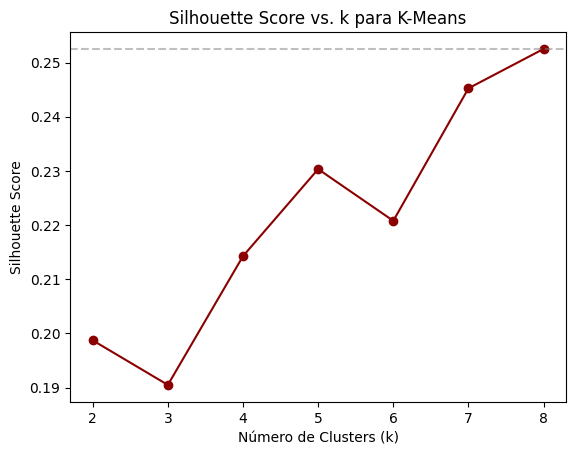


Silhouette Score del modelo final (k=4): 0.2143
Interpretación: valores > 0.5 indican estructura de cluster razonable.


In [35]:
# Parte 4.1.2: Evaluación de K-Means con Silhouette Score
from sklearn.metrics import silhouette_score

# Comparar silhouette para diferentes valores de k
silhouette_scores = []
k_values = range(2, 9)
for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42)
    labels_temp = km_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f'k={k} → Silhouette Score: {score:.4f}')

plt.plot(k_values, silhouette_scores, marker='o', color='darkred')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k para K-Means')
plt.axhline(y=max(silhouette_scores), color='gray', linestyle='--', alpha=0.5)
plt.show()

# Score del modelo final (k=4)
score_final = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'\nSilhouette Score del modelo final (k=4): {score_final:.4f}')
print('Interpretación: valores > 0.5 indican estructura de cluster razonable.')

**DBSCAN**

DBSCAN es un algoritmo de clustering basado en densidad. A diferencia de K-Means (que requiere que definas el número de clusters k)

* Encuentra agrupaciones densas de puntos sin necesidad de saber cuántos clusters hay.

* Identifica automáticamente "ruido" o "outliers", etiquetándolos como -1.

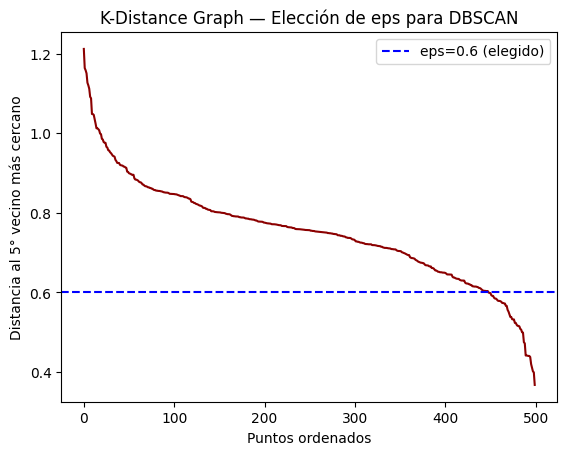

El codo visible en la curva sugiere eps ≈ 0.6, por eso elegimos ese valor.


In [36]:
# Selección de parámetros para DBSCAN (k-distance graph)
from sklearn.neighbors import NearestNeighbors

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distancia al k-ésimo vecino, ordenada de mayor a menor
kth_distances = np.sort(distances[:, min_samples - 1])[::-1]

plt.plot(kth_distances, color='darkred')
plt.axhline(y=0.6, color='blue', linestyle='--', label='eps=0.6 (elegido)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5° vecino más cercano')
plt.title('K-Distance Graph — Elección de eps para DBSCAN')
plt.legend()
plt.show()

print('El codo visible en la curva sugiere eps ≈ 0.6, por eso elegimos ese valor.')

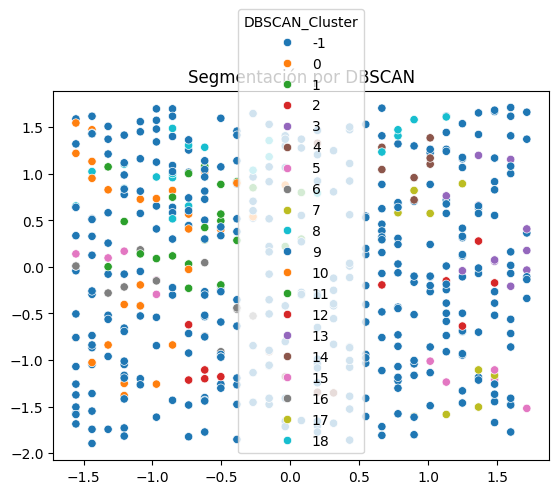

In [37]:
# Clustering con DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5) # eps = radio máximo para considerar que dos puntos están “cerca”./ min_samples =  número mínimo de puntos vecinos necesarios para formar un cluster.
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=df['DBSCAN_Cluster'], palette='tab10')
plt.title('Segmentación por DBSCAN')
plt.show()

In [38]:
# Interpretando los Clustering con DBSCAN
df['DBSCAN_Cluster'].value_counts()
df.groupby('DBSCAN_Cluster')[['age', 'study_hours_per_week', 'attendance_rate','previous_score']].mean()

,age,study_hours_per_week,attendance_rate,previous_score
DBSCAN_Cluster,,,,
-1,17.119777,15.905292,75.494429,62.649025
0,19.000000,7.411765,87.835294,66.764706
1,16.000000,10.941176,85.276471,77.941176
2,15.000000,25.400000,73.960000,88.000000
3,18.000000,28.833333,77.200000,37.333333
4,18.000000,22.125000,91.887500,46.875000
5,15.000000,27.000000,59.580000,68.200000
6,18.000000,5.666667,75.433333,92.833333
7,16.000000,26.000000,57.140000,52.400000


In [39]:
# Interpretando los Clustering con DBSCAN sin atípicos
df_no_noise = df[df['DBSCAN_Cluster'] != -1]
df_no_noise.groupby('DBSCAN_Cluster')[['age', 'study_hours_per_week', 'attendance_rate','previous_score']].mean()

,age,study_hours_per_week,attendance_rate,previous_score
DBSCAN_Cluster,,,,
0,19.0,7.411765,87.835294,66.764706
1,16.0,10.941176,85.276471,77.941176
2,15.0,25.400000,73.960000,88.000000
3,18.0,28.833333,77.200000,37.333333
4,18.0,22.125000,91.887500,46.875000
5,15.0,27.000000,59.580000,68.200000
6,18.0,5.666667,75.433333,92.833333
7,16.0,26.000000,57.140000,52.400000
8,15.0,8.750000,90.318750,71.937500


**Evaluación de DBSCAN con Silhouette Score**

Para DBSCAN excluimos los puntos de ruido (etiqueta -1) del cálculo, ya que no pertenecen a ningún cluster y sesgarían la métrica.

In [40]:
# Evaluación de DBSCAN con Silhouette Score
from sklearn.metrics import silhouette_score

# Solo evaluar sobre puntos que NO son ruido
mask_no_noise = df['DBSCAN_Cluster'] != -1
n_noise = (df['DBSCAN_Cluster'] == -1).sum()
n_clusters_dbscan = df['DBSCAN_Cluster'][mask_no_noise].nunique()

print(f'Puntos clasificados como ruido (-1): {n_noise}')
print(f'Clusters encontrados (sin ruido): {n_clusters_dbscan}')

if n_clusters_dbscan > 1:
    score_dbscan = silhouette_score(
        X_scaled[mask_no_noise],
        df['DBSCAN_Cluster'][mask_no_noise]
    )
    print(f'Silhouette Score DBSCAN (sin ruido): {score_dbscan:.4f}')
else:
    print('Solo 1 cluster → Silhouette Score no aplicable con estos parámetros.')

print('\n¿Por qué DBSCAN encuentra menos clusters que K-Means?')
print('DBSCAN agrupa según densidad, por lo que regiones poco densas quedan como ruido,')
print('en lugar de forzarse a pertenecer a un cluster como lo haría K-Means.')

Puntos clasificados como ruido (-1): 359
Clusters encontrados (sin ruido): 19
Silhouette Score DBSCAN (sin ruido): 0.4084

¿Por qué DBSCAN encuentra menos clusters que K-Means?
DBSCAN agrupa según densidad, por lo que regiones poco densas quedan como ruido,
en lugar de forzarse a pertenecer a un cluster como lo haría K-Means.


**¿Qué es PCA?**

PCA (Principal Component Analysis) es una técnica matemática que:

* Reduce el número de variables (dimensiones) de un dataset.

* Conserva la mayor parte de la variabilidad (información) de los datos originales.

* Transforma los datos a componentes principales que son combinaciones lineales de las variables originales.

¿Qué significa reducir de 3 a 2 dimensiones?

Reduces de:

Tres variables originales (Edad, Ingreso, Gasto)

a:

Dos nuevas variables artificiales, llamadas Componentes principales: PC1 y PC2.

Cada una de estas componentes es una combinación lineal de las variables originales. Por ejemplo:



* PC1=0.5⋅Edad+0.7⋅Ingreso+0.5⋅Gasto


* PC2=−0.6⋅Edad+0.4⋅Ingreso+0.7⋅Gasto

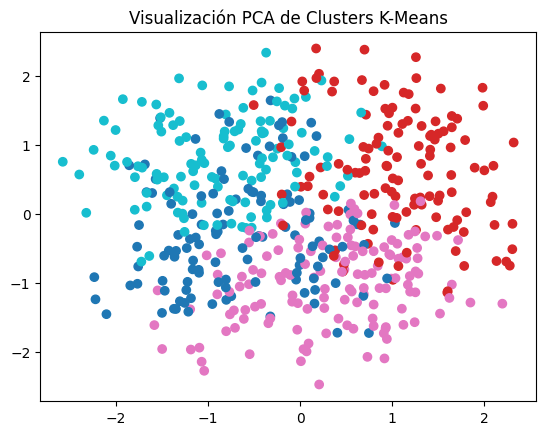

In [41]:
# Reducción de dimensionalidad con PCA K-Means
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='tab10')
plt.title('Visualización PCA de Clusters K-Means')
plt.show()

Varianza explicada por componente:
  PC1: 0.2805 (28.1%)
  PC2: 0.2640 (26.4%)

Varianza total conservada en 2D: 54.5%


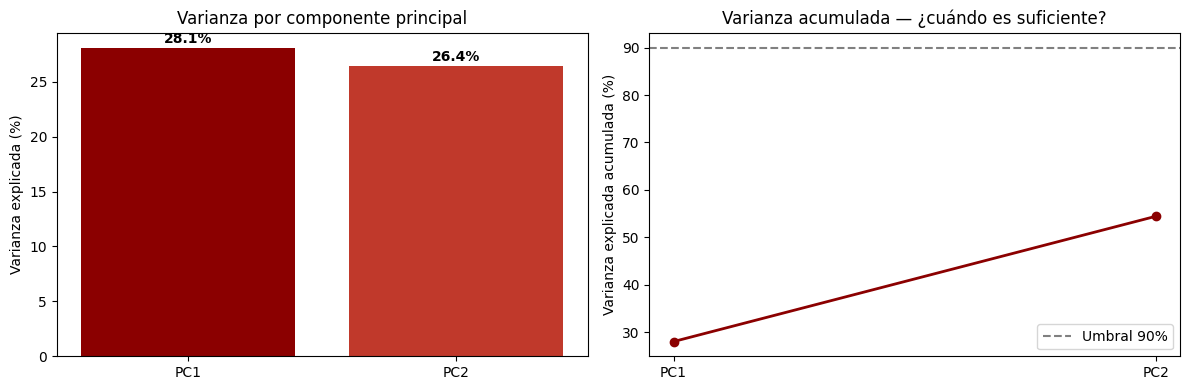


Loadings (contribución de cada variable a cada componente):
                         PC1     PC2
age                  -0.6291 -0.3717
study_hours_per_week -0.1134  0.8452
attendance_rate      -0.3102 -0.2382
previous_score        0.7036 -0.3011


In [42]:
# Varianza explicada por PCA K-Means
print('Varianza explicada por componente:')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)')

print(f'\nVarianza total conservada en 2D: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Gráfica de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Varianza por componente
axes[0].bar(['PC1', 'PC2'], pca.explained_variance_ratio_ * 100, color=['#8B0000', '#C0392B'])
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente principal')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontweight='bold')

# Varianza acumulada
axes[1].plot(['PC1', 'PC2'], np.cumsum(pca.explained_variance_ratio_) * 100,
             marker='o', color='darkred', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='Umbral 90%')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza acumulada — ¿cuándo es suficiente?')
axes[1].legend()

plt.tight_layout()
plt.show()

# Loadings: qué variable aporta más a cada componente
print('\nLoadings (contribución de cada variable a cada componente):')
loadings = pd.DataFrame(
    pca.components_.T,
    index=['age', 'study_hours_per_week', 'attendance_rate','previous_score'],
    columns=['PC1', 'PC2']
)
print(loadings.round(4))

In [43]:
# Interpretación de Reducción de dimensionalidad con PCA
df.groupby('KMeans_Cluster')[['age', 'study_hours_per_week', 'attendance_rate','previous_score']].mean()

,age,study_hours_per_week,attendance_rate,previous_score
KMeans_Cluster,,,,
0,17.691667,10.208333,68.080000,47.008333
1,16.137097,19.532258,64.189516,76.508065
2,16.963768,8.833333,86.236232,75.036232
3,17.152542,23.644068,86.106780,50.932203


In [44]:
# Interpretación detallada de Reducción de dimensionalidad con PCA
# Mostrar algunos clientes por cluster
for i in range(4):
    print(f"\nCluster {i}")
    display(df[df['KMeans_Cluster'] == i][['age', 'study_hours_per_week', 'attendance_rate','previous_score']].head())


Cluster 0


,age,study_hours_per_week,attendance_rate,previous_score
5,19,8,85.2,40
12,19,4,69.2,31
20,19,19,61.5,37
22,19,20,73.6,42
25,18,9,93.7,36



Cluster 1


,age,study_hours_per_week,attendance_rate,previous_score
0,15,25,63.8,41
1,15,2,54.7,83
3,16,26,66.8,75
4,15,25,73.0,67
7,15,21,81.7,89



Cluster 2


,age,study_hours_per_week,attendance_rate,previous_score
2,19,10,90.5,73
6,18,10,72.7,75
8,19,9,84.2,70
9,15,8,95.7,93
15,16,13,88.1,92



Cluster 3


,age,study_hours_per_week,attendance_rate,previous_score
11,16,18,74.7,50
14,15,25,93.8,68
16,17,30,99.3,60
19,18,30,75.9,38
29,19,29,76.6,38


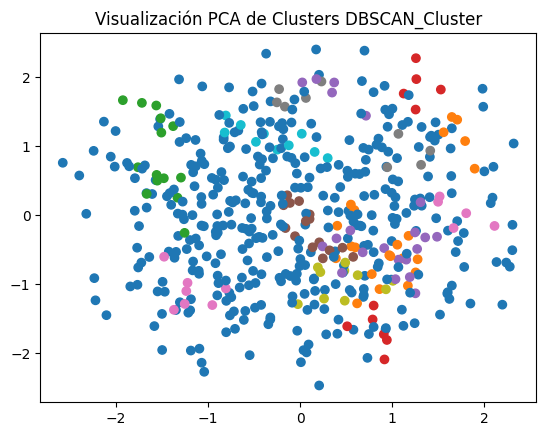

In [45]:
# Reducción de dimensionalidad con PCA DBSCAN_Cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['DBSCAN_Cluster'], cmap='tab10')
plt.title('Visualización PCA de Clusters DBSCAN_Cluster')
plt.show()

Varianza explicada por componente:
  PC1: 0.2805 (28.1%)
  PC2: 0.2640 (26.4%)

Varianza total conservada en 2D: 54.5%


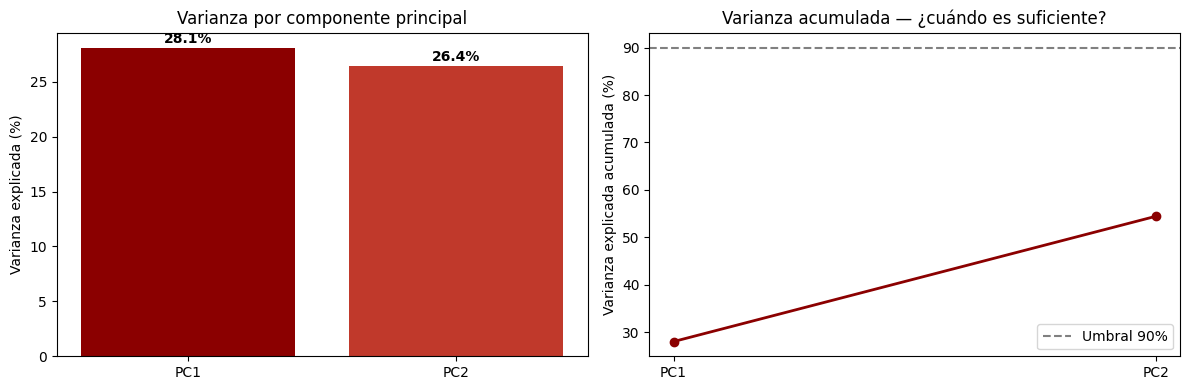


Loadings (contribución de cada variable a cada componente):
                         PC1     PC2
age                  -0.6291 -0.3717
study_hours_per_week -0.1134  0.8452
attendance_rate      -0.3102 -0.2382
previous_score        0.7036 -0.3011


In [46]:
# Varianza explicada por PCA DBSCAN_Cluster
print('Varianza explicada por componente:')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)')

print(f'\nVarianza total conservada en 2D: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Gráfica de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Varianza por componente
axes[0].bar(['PC1', 'PC2'], pca.explained_variance_ratio_ * 100, color=['#8B0000', '#C0392B'])
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente principal')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontweight='bold')

# Varianza acumulada
axes[1].plot(['PC1', 'PC2'], np.cumsum(pca.explained_variance_ratio_) * 100,
             marker='o', color='darkred', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='Umbral 90%')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza acumulada — ¿cuándo es suficiente?')
axes[1].legend()

plt.tight_layout()
plt.show()

# Loadings: qué variable aporta más a cada componente
print('\nLoadings (contribución de cada variable a cada componente):')
loadings = pd.DataFrame(
    pca.components_.T,
    index=['age', 'study_hours_per_week', 'attendance_rate','previous_score'],
    columns=['PC1', 'PC2']
)
print(loadings.round(4))

In [47]:
# Interpretación de Reducción de dimensionalidad con PCA
df.groupby('DBSCAN_Cluster')[['age', 'study_hours_per_week', 'attendance_rate','previous_score']].mean()

,age,study_hours_per_week,attendance_rate,previous_score
DBSCAN_Cluster,,,,
-1,17.119777,15.905292,75.494429,62.649025
0,19.000000,7.411765,87.835294,66.764706
1,16.000000,10.941176,85.276471,77.941176
2,15.000000,25.400000,73.960000,88.000000
3,18.000000,28.833333,77.200000,37.333333
4,18.000000,22.125000,91.887500,46.875000
5,15.000000,27.000000,59.580000,68.200000
6,18.000000,5.666667,75.433333,92.833333
7,16.000000,26.000000,57.140000,52.400000
